# Capítulo 17 — Sobreajuste y subajuste

En los cuadernos anteriores aprendimos a entrenar modelos y a evaluar sus predicciones. Ahora nos concentraremos en una pregunta central: **¿el modelo aprendió patrones que puede aplicar a casos nuevos o solamente se adaptó a los datos que ya conocía?**

Usaremos un árbol de decisión, ya estudiado en el Capítulo 10, para observar tres situaciones: un modelo demasiado simple, uno con un equilibrio razonable y otro demasiado complejo. Después construiremos deliberadamente un caso con fuga de datos para comprobar por qué un resultado perfecto también puede ser una señal de alerta.


## Objetivos del cuaderno

Al finalizar este cuaderno, deberías poder:

- explicar qué significa que un modelo generalice;
- comparar el desempeño en entrenamiento y prueba;
- reconocer señales de subajuste y sobreajuste;
- relacionar la complejidad de un árbol con su profundidad;
- interpretar la brecha entre entrenamiento y prueba;
- comparar un modelo con una referencia simple;
- comprender por qué una variable faltante puede producir subajuste;
- detectar resultados sospechosamente altos;
- distinguir sobreajuste de fuga de datos;
- revisar si una variable estaría disponible en el momento real de predicción.

La validación cruzada y la selección sistemática de hiperparámetros se desarrollarán más adelante.


## 1. Importar las herramientas

Usaremos NumPy y Pandas para organizar los resultados, Matplotlib para visualizar los datos y `scikit-learn` para generar el ejemplo, separar los casos y entrenar los modelos.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap
from sklearn.datasets import make_circles
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier


## 2. Crear un problema didáctico

Generaremos un conjunto sintético de clasificación binaria. Cada fila tiene dos indicadores y pertenece a una de dos clases.

Los datos forman dos regiones aproximadamente circulares. Esta estructura resulta útil porque un árbol con una sola división será demasiado simple, mientras que uno con más profundidad podrá construir una frontera más adecuada.

El ruido agregado representa pequeñas variaciones y casos que no siguen perfectamente el patrón general.


In [2]:
X_array, y_array = make_circles(
    n_samples=350,
    noise=0.16,
    factor=0.45,
    random_state=17,
)

datos = pd.DataFrame(
    X_array,
    columns=["indicador_1", "indicador_2"],
)
datos["clase"] = y_array

datos.head()


,indicador_1,indicador_2,clase
0,0.111280,0.442832,1
1,1.060881,0.174738,0
2,-0.434202,-0.616343,0
3,0.359425,0.383133,1
4,0.474537,0.335550,1


In [3]:
datos["clase"].value_counts().sort_index().rename(
    index={0: "Clase 0", 1: "Clase 1"}
)


clase
Clase 0    175
Clase 1    175
Name: count, dtype: int64

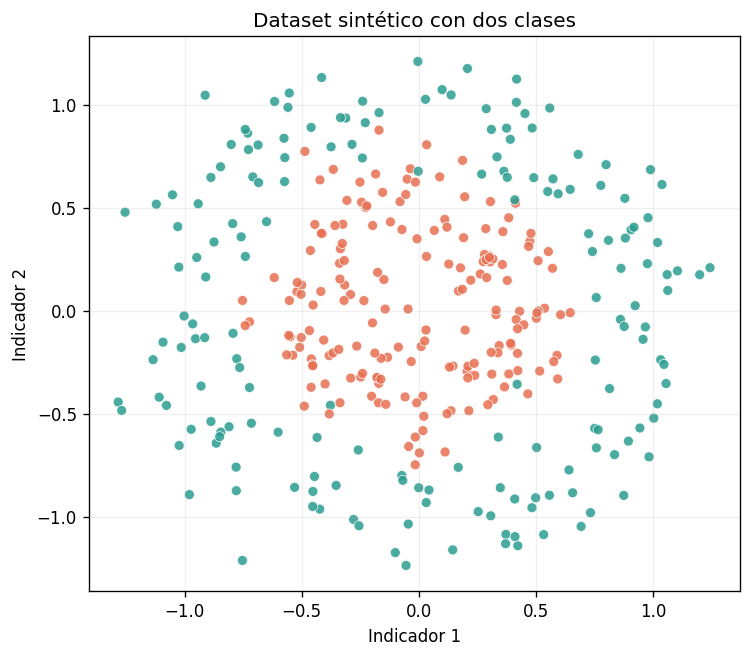

In [4]:
colores_puntos = np.where(
    datos["clase"] == 0,
    "#2A9D8F",
    "#E76F51",
)

plt.figure(figsize=(7, 6))
plt.scatter(
    datos["indicador_1"],
    datos["indicador_2"],
    c=colores_puntos,
    edgecolor="white",
    linewidth=0.5,
    alpha=0.85,
)
plt.xlabel("Indicador 1")
plt.ylabel("Indicador 2")
plt.title("Dataset sintético con dos clases")
plt.grid(alpha=0.2)
plt.show()


Las clases están balanceadas, por lo que una estrategia que siempre predice la misma clase acertará aproximadamente la mitad de los casos.

La figura permite ver una tendencia, pero también puntos cercanos y algunas observaciones mezcladas. Un modelo útil deberá capturar la forma general sin perseguir cada irregularidad.


## 3. Separar entrenamiento y prueba

El modelo aprenderá únicamente con los datos de entrenamiento. Los datos de prueba simularán casos nuevos.

Usaremos `stratify=y` para conservar la proporción de clases y un `random_state` fijo para que la división sea reproducible.


In [5]:
X = datos[["indicador_1", "indicador_2"]]
y = datos["clase"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=17,
    stratify=y,
)

pd.DataFrame({
    "conjunto": ["Entrenamiento", "Prueba"],
    "filas": [len(X_train), len(X_test)],
    "porcentaje_clase_1": [
        y_train.mean() * 100,
        y_test.mean() * 100,
    ],
}).round(2)


,conjunto,filas,porcentaje_clase_1
0,Entrenamiento,245,49.80
1,Prueba,105,50.48


El conjunto de prueba debe permanecer fuera del entrenamiento. Si el modelo aprende de esos casos, la evaluación deja de representar datos no vistos.


## 4. Construir una línea de base

Antes de interpretar un modelo, conviene compararlo con una estrategia mínima. `DummyClassifier` no aprende una frontera: siempre predice la clase más frecuente del entrenamiento.


In [6]:
referencia = DummyClassifier(strategy="most_frequent")
referencia.fit(X_train, y_train)

accuracy_referencia_train = accuracy_score(
    y_train,
    referencia.predict(X_train),
)
accuracy_referencia_test = accuracy_score(
    y_test,
    referencia.predict(X_test),
)

pd.DataFrame({
    "modelo": ["Clase mayoritaria"],
    "accuracy_entrenamiento": [accuracy_referencia_train],
    "accuracy_prueba": [accuracy_referencia_test],
}).round(3)


,modelo,accuracy_entrenamiento,accuracy_prueba
0,Clase mayoritaria,0.502,0.495


La referencia obtiene una accuracy cercana a 0,50. Un modelo que no la mejore de manera clara probablemente no esté aprovechando los indicadores disponibles.


## 5. Entrenar árboles con distinta complejidad

La profundidad máxima controla cuántas decisiones puede encadenar el árbol:

- `max_depth=1`: una sola división, muy poca flexibilidad;
- `max_depth=4`: varias decisiones, pero con un límite;
- `max_depth=None`: sin límite explícito, hasta que el árbol deja de encontrar divisiones posibles.

Usamos el mismo entrenamiento y la misma prueba para que la comparación sea coherente.


In [7]:
arbol_simple = DecisionTreeClassifier(
    max_depth=1,
    random_state=17,
)
arbol_intermedio = DecisionTreeClassifier(
    max_depth=4,
    random_state=17,
)
arbol_complejo = DecisionTreeClassifier(
    max_depth=None,
    random_state=17,
)

modelos = {
    "Demasiado simple": arbol_simple,
    "Complejidad intermedia": arbol_intermedio,
    "Sin límite de profundidad": arbol_complejo,
}

for modelo in modelos.values():
    modelo.fit(X_train, y_train)


## 6. Comparar entrenamiento y prueba

No alcanza con mirar una única accuracy. Para estudiar generalización necesitamos calcular la métrica en los dos conjuntos.

También registraremos:

- la profundidad alcanzada;
- la cantidad de hojas;
- la brecha entre accuracy de entrenamiento y prueba.


In [8]:
def resumir_arbol(nombre, modelo):
    accuracy_train = accuracy_score(
        y_train,
        modelo.predict(X_train),
    )
    accuracy_test = accuracy_score(
        y_test,
        modelo.predict(X_test),
    )

    return {
        "modelo": nombre,
        "profundidad_real": modelo.get_depth(),
        "hojas": modelo.get_n_leaves(),
        "accuracy_entrenamiento": accuracy_train,
        "accuracy_prueba": accuracy_test,
        "brecha": accuracy_train - accuracy_test,
    }


comparacion = pd.DataFrame([
    resumir_arbol(nombre, modelo)
    for nombre, modelo in modelos.items()
])

comparacion.round(3)


,modelo,profundidad_real,hojas,accuracy_entrenamiento,accuracy_prueba,brecha
0,Demasiado simple,1,2,0.653,0.610,0.044
1,Complejidad intermedia,4,9,0.959,0.886,0.073
2,Sin límite de profundidad,8,17,1.000,0.848,0.152


En esta división concreta observamos tres comportamientos:

- el árbol de profundidad 1 obtiene resultados bajos y parecidos en ambos conjuntos: **subajusta**;
- el árbol de profundidad 4 mejora claramente en entrenamiento y prueba: muestra un **equilibrio razonable** para esta demostración;
- el árbol sin límite alcanza accuracy 1,00 en entrenamiento, pero empeora en prueba: presenta una señal de **sobreajuste**.

La brecha no tiene un umbral universal. Debe interpretarse junto con el nivel de desempeño, la referencia, el contexto y la variabilidad de los datos.


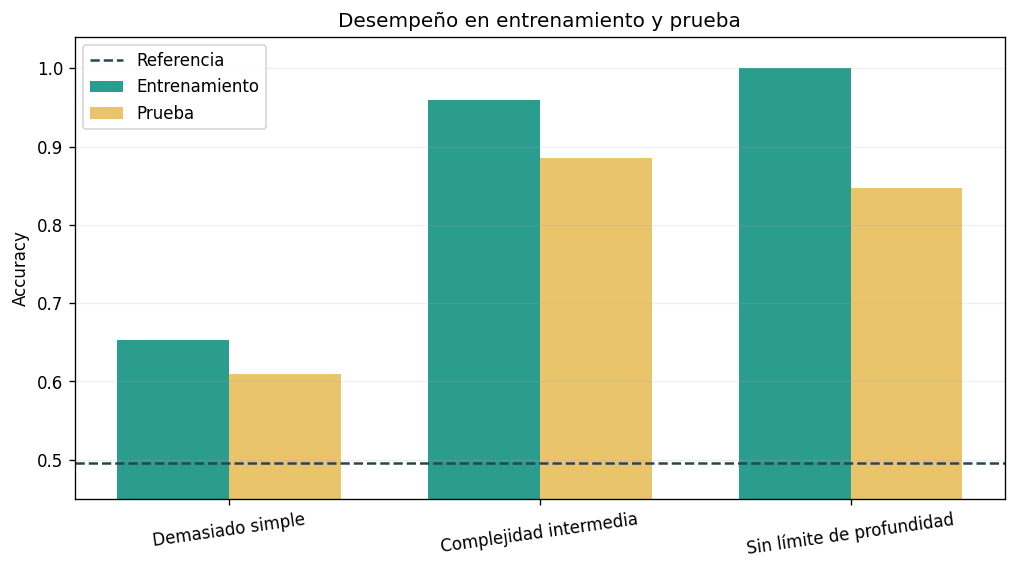

In [9]:
x = np.arange(len(comparacion))
ancho = 0.36

plt.figure(figsize=(10, 5))
plt.bar(
    x - ancho / 2,
    comparacion["accuracy_entrenamiento"],
    width=ancho,
    color="#2A9D8F",
    label="Entrenamiento",
)
plt.bar(
    x + ancho / 2,
    comparacion["accuracy_prueba"],
    width=ancho,
    color="#E9C46A",
    label="Prueba",
)
plt.axhline(
    accuracy_referencia_test,
    color="#264653",
    linestyle="--",
    label="Referencia",
)
plt.xticks(x, comparacion["modelo"], rotation=8)
plt.ylim(0.45, 1.04)
plt.ylabel("Accuracy")
plt.title("Desempeño en entrenamiento y prueba")
plt.legend()
plt.grid(axis="y", alpha=0.2)
plt.show()


Una accuracy de entrenamiento alta no demuestra por sí sola que el modelo sea útil. Lo importante es si ese aprendizaje se sostiene frente a casos no vistos.


## 7. Visualizar las fronteras de decisión

Como solo tenemos dos variables, podemos observar qué región asigna cada árbol a cada clase.


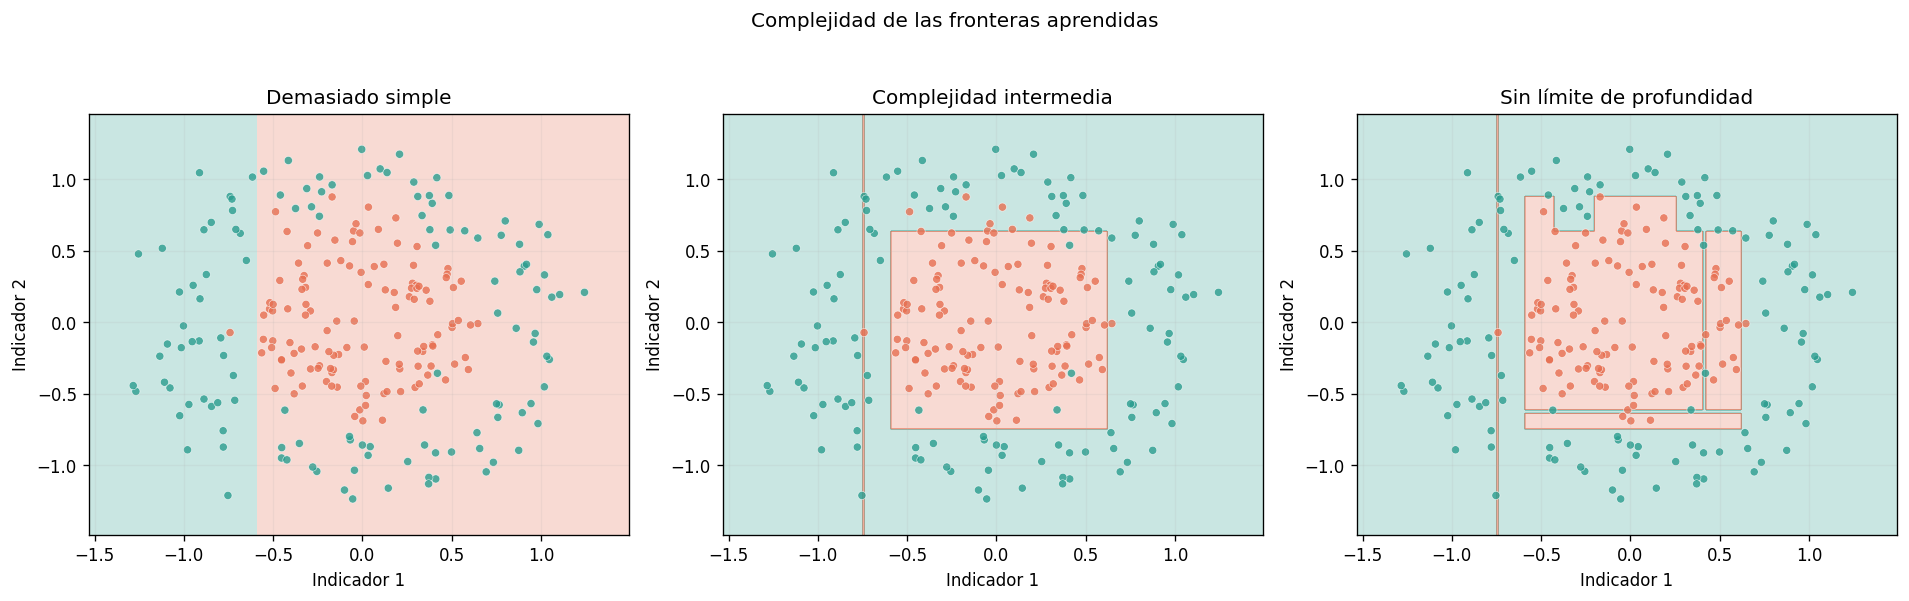

In [10]:
def dibujar_frontera(ax, modelo, titulo):
    margen = 0.25
    x_min = X["indicador_1"].min() - margen
    x_max = X["indicador_1"].max() + margen
    y_min = X["indicador_2"].min() - margen
    y_max = X["indicador_2"].max() + margen

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 350),
        np.linspace(y_min, y_max, 350),
    )
    grilla = pd.DataFrame({
        "indicador_1": xx.ravel(),
        "indicador_2": yy.ravel(),
    })
    regiones = modelo.predict(grilla).reshape(xx.shape)

    ax.contourf(
        xx,
        yy,
        regiones,
        alpha=0.25,
        cmap=ListedColormap(["#2A9D8F", "#E76F51"]),
    )
    ax.scatter(
        X_train["indicador_1"],
        X_train["indicador_2"],
        c=y_train,
        cmap=ListedColormap(["#2A9D8F", "#E76F51"]),
        edgecolor="white",
        linewidth=0.35,
        s=24,
        alpha=0.8,
    )
    ax.set_title(titulo)
    ax.set_xlabel("Indicador 1")
    ax.set_ylabel("Indicador 2")
    ax.grid(alpha=0.15)


fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

for ax, (nombre, modelo) in zip(axes, modelos.items()):
    dibujar_frontera(ax, modelo, nombre)

plt.suptitle("Complejidad de las fronteras aprendidas", y=1.03)
plt.tight_layout()
plt.show()


El primer árbol solo puede construir una separación muy básica y deja sin capturar gran parte del patrón circular.

El árbol intermedio crea una región más adecuada sin dividir cada pequeño detalle.

El árbol sin límite produce una frontera irregular, con recortes destinados a clasificar casos particulares del entrenamiento. Esa flexibilidad explica su accuracy perfecta en los datos conocidos, pero no mejora los casos nuevos.


## 8. Observar qué ocurre al aumentar la profundidad

Entrenaremos árboles con profundidades de 1 a 15. Esta comparación tiene un propósito didáctico: observar la relación entre complejidad y desempeño. No constituye todavía un procedimiento formal para elegir hiperparámetros.


In [11]:
resultados_profundidad = []

for profundidad in range(1, 16):
    modelo = DecisionTreeClassifier(
        max_depth=profundidad,
        random_state=17,
    )
    modelo.fit(X_train, y_train)

    resultados_profundidad.append({
        "profundidad": profundidad,
        "accuracy_entrenamiento": accuracy_score(
            y_train,
            modelo.predict(X_train),
        ),
        "accuracy_prueba": accuracy_score(
            y_test,
            modelo.predict(X_test),
        ),
        "hojas": modelo.get_n_leaves(),
    })

resultados_profundidad = pd.DataFrame(
    resultados_profundidad
)
resultados_profundidad.round(3)


,profundidad,accuracy_entrenamiento,accuracy_prueba,hojas
0,1,0.653,0.610,2
1,2,0.784,0.743,4
2,3,0.878,0.810,7
3,4,0.959,0.886,9
4,5,0.959,0.886,11
5,6,0.980,0.876,14
6,7,0.996,0.867,16
7,8,1.000,0.848,17
8,9,1.000,0.848,17
9,10,1.000,0.848,17


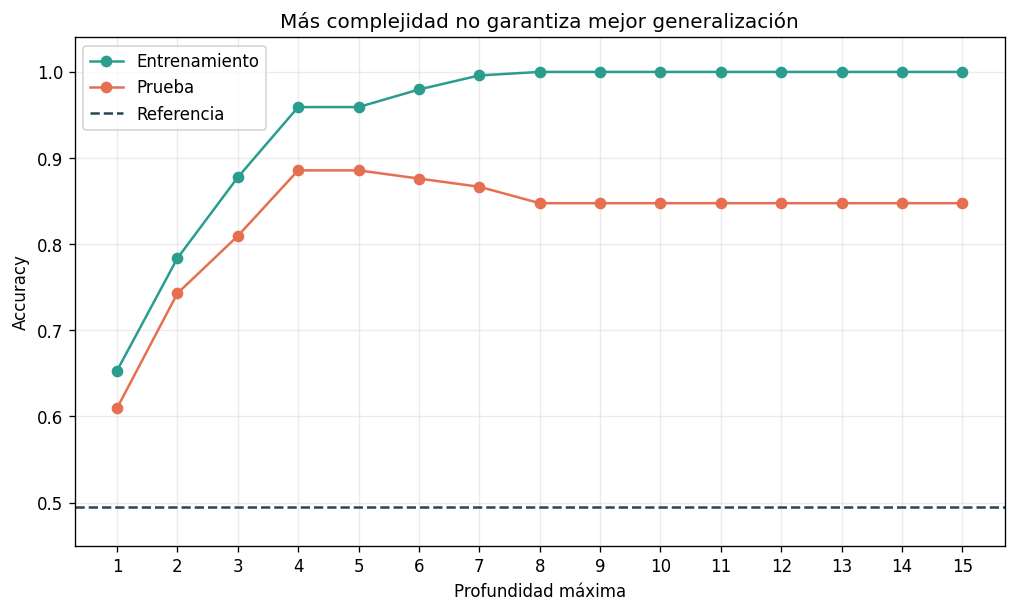

In [12]:
plt.figure(figsize=(10, 5.5))
plt.plot(
    resultados_profundidad["profundidad"],
    resultados_profundidad["accuracy_entrenamiento"],
    marker="o",
    color="#2A9D8F",
    label="Entrenamiento",
)
plt.plot(
    resultados_profundidad["profundidad"],
    resultados_profundidad["accuracy_prueba"],
    marker="o",
    color="#E76F51",
    label="Prueba",
)
plt.axhline(
    accuracy_referencia_test,
    color="#264653",
    linestyle="--",
    label="Referencia",
)
plt.xlabel("Profundidad máxima")
plt.ylabel("Accuracy")
plt.title("Más complejidad no garantiza mejor generalización")
plt.xticks(range(1, 16))
plt.ylim(0.45, 1.04)
plt.legend()
plt.grid(alpha=0.25)
plt.show()


La accuracy de entrenamiento crece hasta llegar a 1,00. Esto es esperable: al darle más flexibilidad, el árbol puede ajustar mejor los datos que ya vio.

La accuracy de prueba no mejora de forma permanente. Primero aumenta porque el modelo deja de ser demasiado simple; luego se estanca o cae cuando las divisiones empiezan a capturar detalles particulares.

No estamos buscando aquí “la profundidad ganadora”. Para elegir configuraciones con más estabilidad necesitaremos la validación cruzada del próximo capítulo.


## 9. Otra causa de subajuste: información insuficiente

El subajuste no depende únicamente de la profundidad. Un modelo también puede aprender poco porque faltan variables relevantes.

Entrenaremos dos árboles de profundidad 4:

- uno recibe únicamente `indicador_1`;
- el otro recibe ambos indicadores.


In [13]:
arbol_una_variable = DecisionTreeClassifier(
    max_depth=4,
    random_state=17,
)
arbol_dos_variables = DecisionTreeClassifier(
    max_depth=4,
    random_state=17,
)

arbol_una_variable.fit(
    X_train[["indicador_1"]],
    y_train,
)
arbol_dos_variables.fit(
    X_train,
    y_train,
)

comparacion_variables = pd.DataFrame({
    "variables_disponibles": [
        "Solo indicador_1",
        "Indicador_1 e indicador_2",
    ],
    "accuracy_entrenamiento": [
        accuracy_score(
            y_train,
            arbol_una_variable.predict(
                X_train[["indicador_1"]]
            ),
        ),
        accuracy_score(
            y_train,
            arbol_dos_variables.predict(X_train),
        ),
    ],
    "accuracy_prueba": [
        accuracy_score(
            y_test,
            arbol_una_variable.predict(
                X_test[["indicador_1"]]
            ),
        ),
        accuracy_score(
            y_test,
            arbol_dos_variables.predict(X_test),
        ),
    ],
})

comparacion_variables.round(3)


,variables_disponibles,accuracy_entrenamiento,accuracy_prueba
0,Solo indicador_1,0.812,0.705
1,Indicador_1 e indicador_2,0.959,0.886


El árbol que recibe una sola variable funciona peor tanto en entrenamiento como en prueba. Aumentar únicamente la complejidad no puede reconstruir una señal que no está en los datos de entrada.

Ante un posible subajuste debemos revisar el problema completo: algoritmo, hiperparámetros, variables disponibles, representación, preprocesamiento y calidad de los datos.


## 10. Reconocer patrones de diagnóstico

La relación entre entrenamiento y prueba orienta el análisis, pero no produce diagnósticos automáticos.


In [14]:
escenarios = pd.DataFrame({
    "accuracy_entrenamiento": [
        0.62,
        0.99,
        0.84,
        0.99,
    ],
    "accuracy_prueba": [
        0.60,
        0.72,
        0.81,
        0.98,
    ],
    "lectura_inicial": [
        "Posible subajuste o poca señal",
        "Posible sobreajuste",
        "Generalización razonable",
        "Resultado sospechosamente alto: revisar",
    ],
})

escenarios["brecha"] = (
    escenarios["accuracy_entrenamiento"]
    - escenarios["accuracy_prueba"]
)

escenarios.round(3)


,accuracy_entrenamiento,accuracy_prueba,lectura_inicial,brecha
0,0.62,0.60,Posible subajuste o poca señal,0.02
1,0.99,0.72,Posible sobreajuste,0.27
2,0.84,0.81,Generalización razonable,0.03
3,0.99,0.98,Resultado sospechosamente alto: revisar,0.01


El tercer escenario no es automáticamente “bueno”: todavía habría que compararlo con una referencia, elegir métricas apropiadas y revisar errores por clase o grupo.

El cuarto escenario tampoco es automáticamente “excelente”. Una diferencia pequeña entre entrenamiento y prueba no descarta fuga de datos. Si ambos conjuntos contienen una pista indebida, las dos métricas pueden quedar infladas.


## 11. Crear deliberadamente una fuga de datos

Imaginemos que la clase representa un evento futuro. Añadiremos una columna llamada `resultado_posterior` que se completa **después** de ocurrido ese evento.

Para que el problema sea visible, la columna copiará exactamente la variable objetivo. Es una variable inválida: no existiría en el momento real de predicción.


In [15]:
datos_con_fuga = datos.copy()
datos_con_fuga["resultado_posterior"] = y

variables_con_fuga = [
    "indicador_1",
    "indicador_2",
    "resultado_posterior",
]

X_train_fuga = datos_con_fuga.loc[
    X_train.index,
    variables_con_fuga,
]
X_test_fuga = datos_con_fuga.loc[
    X_test.index,
    variables_con_fuga,
]

X_train_fuga.head()


,indicador_1,indicador_2,resultado_posterior
296,0.186234,0.103236,1
87,-0.844951,-0.590119,0
250,-0.318021,0.242954,1
106,-0.846414,0.698088,0
347,0.410969,-1.097726,0


Aunque el nombre de la columna advierte el problema, en un proyecto real la fuga puede estar escondida en un estado administrativo, un acumulado, una fecha o una variable calculada con información futura.


In [16]:
modelo_con_fuga = DecisionTreeClassifier(
    max_depth=4,
    random_state=17,
)
modelo_con_fuga.fit(X_train_fuga, y_train)

comparacion_fuga = pd.DataFrame({
    "flujo": [
        "Variables válidas",
        "Incluye resultado_posterior",
    ],
    "accuracy_entrenamiento": [
        accuracy_score(
            y_train,
            arbol_intermedio.predict(X_train),
        ),
        accuracy_score(
            y_train,
            modelo_con_fuga.predict(X_train_fuga),
        ),
    ],
    "accuracy_prueba": [
        accuracy_score(
            y_test,
            arbol_intermedio.predict(X_test),
        ),
        accuracy_score(
            y_test,
            modelo_con_fuga.predict(X_test_fuga),
        ),
    ],
})

comparacion_fuga.round(3)


,flujo,accuracy_entrenamiento,accuracy_prueba
0,Variables válidas,0.959,0.886
1,Incluye resultado_posterior,1.000,1.000


El modelo con fuga obtiene accuracy perfecta en entrenamiento y prueba. Sin embargo, no aprendió a anticipar el evento: leyó una consecuencia que ya contiene la respuesta.

Esto no es el mismo fenómeno que el sobreajuste:

- el árbol sobreajustado memoriza detalles del entrenamiento y muestra una brecha frente a prueba;
- el modelo con fuga puede parecer excelente en ambos conjuntos porque la pista inválida también está presente en prueba.


In [17]:
importancias_fuga = pd.DataFrame({
    "variable": variables_con_fuga,
    "importancia": modelo_con_fuga.feature_importances_,
}).sort_values(
    "importancia",
    ascending=False,
)

importancias_fuga


,variable,importancia
2,resultado_posterior,1.0
0,indicador_1,0.0
1,indicador_2,0.0


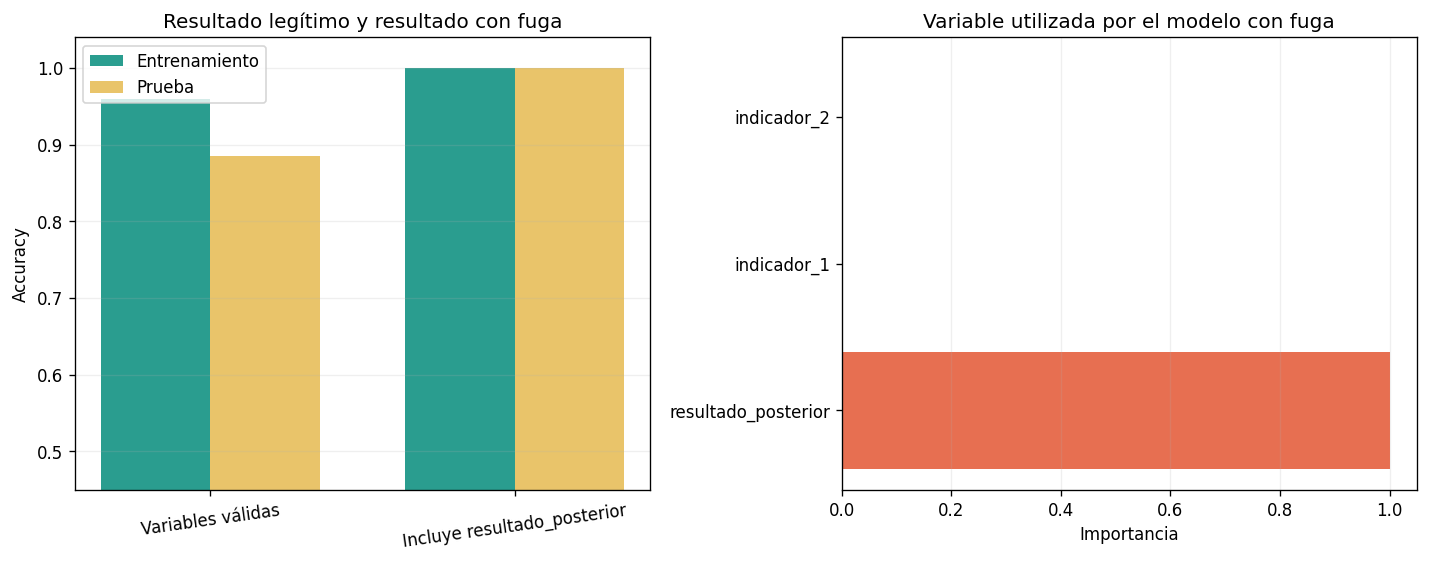

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

x = np.arange(len(comparacion_fuga))
axes[0].bar(
    x - 0.18,
    comparacion_fuga["accuracy_entrenamiento"],
    width=0.36,
    color="#2A9D8F",
    label="Entrenamiento",
)
axes[0].bar(
    x + 0.18,
    comparacion_fuga["accuracy_prueba"],
    width=0.36,
    color="#E9C46A",
    label="Prueba",
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(
    comparacion_fuga["flujo"],
    rotation=8,
)
axes[0].set_ylim(0.45, 1.04)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Resultado legítimo y resultado con fuga")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.2)

axes[1].barh(
    importancias_fuga["variable"],
    importancias_fuga["importancia"],
    color=["#E76F51", "#2A9D8F", "#2A9D8F"],
)
axes[1].set_xlim(0, 1.05)
axes[1].set_xlabel("Importancia")
axes[1].set_title("Variable utilizada por el modelo con fuga")
axes[1].grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()


La importancia concentrada en `resultado_posterior` es una señal evidente en este ejemplo. En la práctica, las importancias no prueban por sí solas que exista fuga, pero una variable dominante y difícil de justificar merece revisión.

Al quitar la columna inválida, la métrica baja. Esa caída no empeora la evaluación: la vuelve **más honesta**.


## 12. Revisar el momento de predicción

Antes de incluir una variable en `X`, conviene responder:

1. ¿En qué momento exacto se hará la predicción?
2. ¿La variable existe en ese instante?
3. ¿Fue calculada únicamente con información anterior?
4. ¿Depende directa o indirectamente de la respuesta?
5. ¿Estará disponible para todos los casos nuevos?

Una columna no es válida solo por tener un nombre razonable. También importa cómo y cuándo fue construida.


## 13. Otras señales de alerta

Además de la brecha entre entrenamiento y prueba, conviene investigar:

- resultados perfectos o casi perfectos;
- desempeño apenas superior a una referencia;
- errores concentrados en una clase, grupo o rango;
- patrones sistemáticos en residuos;
- cambios grandes ante pequeñas modificaciones de los datos;
- duplicados o casos relacionados en entrenamiento y prueba;
- variables dominantes que no estarán disponibles en producción;
- predicciones incoherentes con el conocimiento del problema;
- preprocesamiento aprendido antes de separar los datos;
- uso repetido del conjunto de prueba para tomar decisiones.

Una señal de alerta no cierra el diagnóstico: abre una pregunta.


### Una comparación prudente

Los resultados de este cuaderno provienen de un dataset sintético y de una única separación train/test. Sirven para visualizar conceptos, no para afirmar que `max_depth=4` sea una configuración universalmente adecuada.

Además, un buen desempeño en test supone que los casos futuros se parecerán razonablemente a los datos usados aquí. Un cambio de población, período o contexto puede modificar el resultado.


## 14. Actividad breve

Modificá `profundidad_actividad` y ejecutá la celda. Podés probar con valores entre 1 y 12.


In [19]:
profundidad_actividad = 3

modelo_actividad = DecisionTreeClassifier(
    max_depth=profundidad_actividad,
    random_state=17,
)
modelo_actividad.fit(X_train, y_train)

accuracy_train_actividad = accuracy_score(
    y_train,
    modelo_actividad.predict(X_train),
)
accuracy_test_actividad = accuracy_score(
    y_test,
    modelo_actividad.predict(X_test),
)

pd.DataFrame({
    "profundidad_solicitada": [
        profundidad_actividad
    ],
    "profundidad_real": [
        modelo_actividad.get_depth()
    ],
    "hojas": [
        modelo_actividad.get_n_leaves()
    ],
    "accuracy_entrenamiento": [
        accuracy_train_actividad
    ],
    "accuracy_prueba": [
        accuracy_test_actividad
    ],
    "brecha": [
        accuracy_train_actividad
        - accuracy_test_actividad
    ],
}).round(3)


,profundidad_solicitada,profundidad_real,hojas,accuracy_entrenamiento,accuracy_prueba,brecha
0,3,3,7,0.878,0.81,0.068


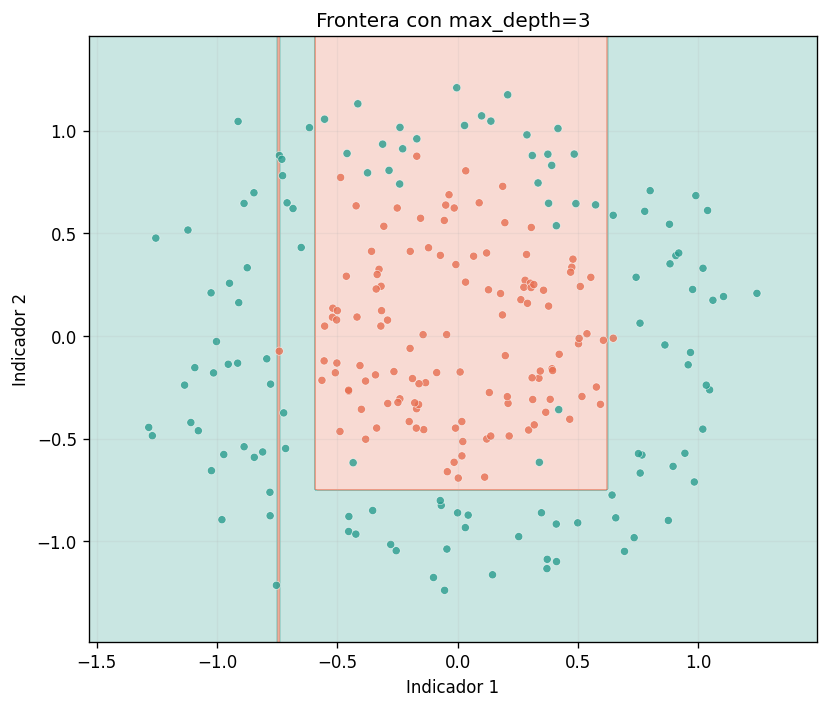

In [20]:
fig, ax = plt.subplots(figsize=(7, 6))
dibujar_frontera(
    ax,
    modelo_actividad,
    (
        "Frontera con "
        f"max_depth={profundidad_actividad}"
    ),
)
plt.tight_layout()
plt.show()


Después de probar varias profundidades, respondé:

1. ¿A partir de qué valor la accuracy de entrenamiento llega a 1,00?
2. ¿La accuracy de prueba aumenta siempre al incrementar la profundidad?
3. ¿Cómo cambia la cantidad de hojas?
4. ¿En qué valores aparece una señal de subajuste?
5. ¿En qué valores aparece una señal de sobreajuste?
6. ¿Por qué esta actividad no alcanza para elegir una profundidad definitiva?


## 15. Síntesis

En este cuaderno:

- usamos entrenamiento y prueba para estudiar generalización;
- construimos una referencia basada en la clase mayoritaria;
- comparamos árboles con distinta profundidad;
- reconocimos subajuste en un modelo demasiado simple;
- reconocimos sobreajuste en un modelo que memoriza entrenamiento;
- visualizamos cómo cambia la frontera de decisión;
- comprobamos que más complejidad no garantiza mejor prueba;
- observamos que la falta de variables puede limitar el aprendizaje;
- relacionamos resultados perfectos con posibles errores metodológicos;
- construimos deliberadamente una fuga de datos;
- distinguimos fuga de datos de sobreajuste;
- revisamos el momento real de disponibilidad de una variable.

El objetivo no es maximizar el desempeño sobre los casos conocidos. Es aprender lo suficiente para capturar patrones útiles, sin perseguir detalles que no se sostendrán en datos nuevos.


## Para pensar

1. ¿Por qué una accuracy alta en entrenamiento no demuestra generalización?
2. Si entrenamiento y prueba tienen accuracy baja y parecida, ¿qué causas revisarías?
3. ¿Qué diferencia existe entre sobreajuste y fuga de datos?
4. ¿Por qué una brecha pequeña entre entrenamiento y prueba no descarta fuga?
5. ¿Qué información aporta una referencia simple?
6. ¿Por qué una variable puede ser inválida aunque esté presente en el dataset?
7. ¿Qué riesgo existe al usar muchas veces el conjunto de prueba para elegir configuraciones?
8. Si un modelo complejo mejora muy poco frente a uno simple, ¿qué otros criterios considerarías?
9. ¿Qué cambiaría si los casos futuros provinieran de una población distinta?
10. ¿Por qué una métrica más baja, pero obtenida con un flujo correcto, puede ser preferible?
